# imports or requirmentss

In [1]:
%%capture
pip install --upgrade pip

In [2]:
%%capture
pip install xgboost lightgbm catboost

In [3]:
%%capture
def _pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].replace("-", "_"))
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for pkg in ["holidays", "fairlearn"]:
    _pip_install(pkg)

In [15]:
import warnings, math
warnings.filterwarnings("ignore")
import calendar
import numpy as np
import pandas as pd
from pandas.api.types import is_datetime64_any_dtype, is_object_dtype, is_string_dtype
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from dataclasses import dataclass, field
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import holidays

import sys, json, math, typing as t


# Métricas y visuales
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, precision_score, recall_score,
    brier_score_loss,precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import TimeSeriesSplit,train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.utils import Bunch
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference

# Opcionales (se activan si están instalados)
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier, Pool
    HAS_CAT = True
except Exception:
    HAS_CAT = False
    

RNG_SEED = 42
np.random.seed(RNG_SEED)
PD_DISPLAY = 200
pd.set_option("display.max_columns", PD_DISPLAY)

# Config + mappings + constantes

In [19]:
@dataclass
class Config:
    project_id: str = "spin-aip-singularity-comp-sb"
    table_fqn: str = "spin-aip-singularity-comp-sb.model_activation.dataste_model_activation_timewindow_reduction_V-1-4-1"
    label_col: str = "label_activated_30d"
    signup_ts_col: str = "signup_ts"
    signup_date_col: str = "signup_date"
    tz_local: str = "America/Mexico_City"

    # train
    n_splits: int = 5
    train_sample_frac: float = 1.0  # puedes bajar a 0.3 para pruebas rápidas
    random_state: int = RNG_SEED

    # evaluation
    lift_fracs: t.Tuple[float, ...] = (0.01, 0.02, 0.05, 0.10)
    budget_fracs: t.Tuple[float, ...] = (0.01, 0.02, 0.05, 0.10)

CFG = Config()

# === 1.1) Columnas a ignorar (potencial leakage / IDs) ===
LEAKY_ALWAYS = {
    "activation_date_ever","activation_date_30d","label_5tx_30d",
    "tx_30d_count","tx_30d_amount","first_tx_type","first_tx_amount",
    "activation_channel","latest_tx_date","tx_30d_from_activation",
    "days_to_first_activation","days_to_first_activation_fix",
    "lifespan_days","days_since_last","IsActive",
    "user_id", "userid",
    "channelUserIdentifier",
    "premia_accountid", "accountid", "member_id",
    "spin_user_id", "id"
}

# === 1.2) Normalización de estados (stateName -> siglas) ===
# Helper: quitar acentos y uniformar
import unicodedata, re
def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^A-Z ]", "", s.upper())
    return re.sub(r"\s+", " ", s).strip()

STATE_TO_ABBR = {
    "AGUASCALIENTES": "AG", "BAJA CALIFORNIA": "BC", "BAJA CALIFORNIA SUR": "BS",
    "CAMPECHE": "CM", "CHIAPAS": "CS", "CHIHUAHUA": "CH", "CIUDAD DE MEXICO": "DF",
    "COAHUILA": "CO", "COLIMA": "CL", "DURANGO": "DG", "GUANAJUATO": "GT",
    "GUERRERO": "GR", "HIDALGO": "HG", "JALISCO": "JA", "MEXICO": "EM",
    "MICHOACAN": "MI", "MORELOS": "MO", "NAYARIT": "NA", "NUEVO LEON": "NL",
    "OAXACA": "OA", "PUEBLA": "PU", "QUERETARO": "QT", "QUINTANA ROO": "QR",
    "SAN LUIS POTOSI": "SL", "SINALOA": "SI", "SONORA": "SO", "TABASCO": "TB",
    "TAMAULIPAS": "TM", "TLAXCALA": "TL", "VERACRUZ": "VE", "YUCATAN": "YU",
    "ZACATECAS": "ZA",
}
# Sinónimos comunes
STATE_SYNONYMS = {
    "CDMX": "CIUDAD DE MEXICO", "ESTADO DE MEXICO": "MEXICO", "EDOMEX": "MEXICO",
}

# === 1.3) birthState -> buckets regionales ===
# Aceptamos códigos heterogéneos vistos: e.g., SR~SO, VZ~VE, YN~YU, JC~JA, MC~MI, TS~TM, TC~TB, CC~CL, MS? (lo mapeamos prudente)
CANON = {
    "SR":"SO","SO":"SO",
    "VZ":"VE","VE":"VE",
    "YN":"YU","YU":"YU",
    "JC":"JA","JA":"JA",
    "MC":"MI","MI":"MI",
    "TS":"TM","TM":"TM",
    "TC":"TB","TB":"TB",
    "CC":"CL","CL":"CL",
    "DF":"DF","EM":"EM","NL":"NL","BC":"BC","BS":"BS","SI":"SI","NA":"NA","DG":"DG","ZA":"ZA",
    "AG":"AG","SL":"SL","HG":"HG","MO":"MO","TL":"TL","PU":"PU","QT":"QT","GT":"GT","OA":"OA",
    "CM":"CM","CS":"CS","CO":"CO","GR":"GR","QR":"QR","CH":"CH","CM":"CM",
    "MS":"MI","MN":"MI","SP":"SL","NE":"NL","OC":"OA","PL":"PU","NT":"NA","ZS":"ZA","AS":"AG",
    "UN":"OT", None:"OT"
}

REGION_BUCKET = {
    # 1 Norte
    "BC":1, "SO":1, "CH":1, "CO":1, "NL":1, "TM":1,
    # 2 Norte-Occidente
    "BS":2, "SI":2, "NA":2, "DG":2, "ZA":2,
    # 3 Centro-Norte
    "JA":3, "AG":3, "CL":3, "MI":3, "SL":3,
    # 4 Centro-País
    "DF":4, "EM":4, "HG":4, "MO":4, "TL":4, "PU":4, "QT":4, "GT":4,
    # 5 Sur-Sureste
    "CS":5, "TB":5, "CM":5, "YU":5, "QR":5, "OA":5, "GR":5, "VE":5,
    # Otros/Unknown
    "OT":0
}

# === 1.4) Mapeos de categorías (exactamente como pediste) ===
GENDER_MAP = {"female":1, "male":0}
USER_TYPE_MAP = {"HYBRID":0, "DIGITAL":1, "ANALOG":2}
CHANNEL_DETAIL_MAP = {
    "ORGANIC":0, "COLLABORATOR":1, "POS":2, "SPIN_PREMIA":3, "DIGITAL_ORGANIC":4, "DIGITAL":5
}

# first_tx_type: definimos trinary por si lo quieres en el 2do modelo (pero NO lo usamos aquí por leakage)
PHYSICAL_TX = {
    "CASH_IN_AT_OXXO","CASH_IN_AT_OXXO_QR","CASH_OUT_WITH_CARD_AT_OXXO",
    "CASH_OUT_AT_OXXO","CASH_OUT_AT_MERCHANT","CARD_PURCHASE","CARD_ATM_WITHDRAWAL"
}
DIGITAL_TX = {
    "SPEI_CASH_IN","P2P_TRANSFER_TARGET_CLABE","P2P_TRANSFER_TARGET",
    "P2P_TRANSFER_TARGET_CARD","P2P_TRANSFER_SOURCE_CARD","P2P_TRANSFER_SOURCE_CLABE",
    "P2P_TRANSFER_SOURCE","TRANSFER_TO_CARD","TRANSFER_TO_CLABE",
    "IN_APP_PURCHASE_TAE","IN_APP_PURCHASE_BILLPAYMENT","QR_MERCHANT_PAYMENT",
    "GIFT_CARD_PURCHASE","INTERNATIONAL_REMITTANCE_CASH_IN"
}


EXTRA_DROP_TS = {"phone_conf_ts", "email_conf_ts"}  # timestamps que podrían ser futuro


# Data Load

In [10]:
from google.cloud import bigquery
client = bigquery.Client(project="spin-aip-singularity-comp-sb")

query = """
SELECT * 
FROM `spin-aip-singularity-comp-sb.model_activation.dataste_model_activation_timewindow_reduction_V-1-4-1` 
"""
data = client.query(query).to_dataframe()

In [11]:
data.head()

,user_id,signup_date,signup_ts,userTypeIdentifier,channelUserIdentifier,accountLevel,stateName,gender,user_type,channelDetail,birth_date,birthState,Card_linked_date,IsActive,phn_confir,email_confir,phone_conf_ts,email_conf_ts,phn_confir_d7,email_confir_d7,both_confir_d7,premia_accountid,has_premia,activation_date_ever,activation_date_30d,label_activated_30d,tx_30d_count,tx_30d_amount,label_5tx_30d,first_tx_type,first_tx_amount,activation_channel,latest_tx_date,lifespan_days,days_since_last,tx_30d_from_activation,days_to_first_activation
0,cf810547-aca0-452e-be9a-1d817cea671c,2025-06-12,2025-06-12 22:41:20.035000+00:00,3,1,2,CH,male,HYBRID,POS,1979-08-14,CH,2025-06-12,True,1,1,2025-06-13 04:48:05.518000+00:00,2025-06-16 01:13:52.529000+00:00,1,1,1,Y8D59C5,1,2025-06-12,2025-06-12,1,63,24095.95,1,CASH_IN_AT_OXXO,5410.00,CashIn_OXXO,2025-10-24,135,4,63,0
1,cf81de8a-b635-449f-8d80-2a72977bad9c,2025-01-27,2025-01-27 18:27:21.105000+00:00,1,1,1,CL,male,ANALOG,POS,1978-09-28,CM,2025-01-27,True,0,0,NaT,NaT,0,0,0,84B6W17,1,2025-01-29,2025-01-29,1,40,6137.90,1,SPEI_CASH_IN,179.00,SPEI/Transfer,2025-02-22,25,248,40,2
2,cf832492-786d-4f4a-b1f5-1cfee36be497,2025-07-17,2025-07-17 22:21:20.431000+00:00,3,1,2,CH,male,HYBRID,POS,1996-12-26,TS,2025-07-17,True,1,0,2025-07-18 04:35:02.735000+00:00,NaT,1,0,0,AJMICC8,1,2025-07-17,2025-07-17,1,34,34258.46,1,CARD_PURCHASE,1073.80,Card,2025-10-26,102,2,34,0
3,cf844863-f2c1-427b-ab95-a167071c7dfe,2025-05-01,2025-05-01 16:44:03.948000+00:00,3,2,2,PL,female,HYBRID,ORGANIC,2003-06-30,PL,2025-05-01,True,1,1,2025-05-01 22:44:11.011000+00:00,2025-05-01 23:47:37.046000+00:00,1,1,1,FU6S3AS,1,2025-05-01,2025-05-01,1,46,17733.94,1,TRANSFER_TO_CARD,7799.94,SPEI/Transfer,2025-10-24,177,4,46,0
4,cf8667c9-d304-40ea-ae26-d5ff8cc1faf7,2025-05-22,2025-05-22 17:00:19.222000+00:00,3,1,3,CH,female,HYBRID,POS,1975-03-04,CH,2025-05-22,True,1,1,2025-08-03 03:22:01.076000+00:00,2025-08-03 03:41:34.924000+00:00,0,0,0,7HMPF3E,1,2025-08-02,NaT,0,<NA>,NaN,0,TRANSFER_TO_CARD,14385.00,SPEI/Transfer,2025-10-26,86,2,78,72


# Feature Engineering

In [20]:
class FeatureBuilder:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.ohe_states_: t.List[str] = []  # para columnas OHE de state_abbr

    @staticmethod
    def _state_to_abbr(s: t.Any) -> str:
        if pd.isna(s):
            return "OT"
        s = str(s)
        # si ya viene como sigla válida:
        if s.upper() in REGION_BUCKET:
            return s.upper()
        # normalizar nombre largo
        s2 = _norm(s)
        s2 = STATE_SYNONYMS.get(s2, s2)
        return STATE_TO_ABBR.get(s2, "OT")

    @staticmethod
    def _canon_birthstate(s: t.Any) -> str:
        if pd.isna(s):
            return "OT"
        s = str(s).upper()
        return CANON.get(s, s if s in REGION_BUCKET else "OT")

    def _mk_time_feats(self, df: pd.DataFrame) -> pd.DataFrame:
        ts = df[self.cfg.signup_ts_col].dt.tz_convert(ZoneInfo(self.cfg.tz_local))
        df = df.copy()
        df["signup_dow"] = ts.dt.weekday.astype("int16")               # 0=Mon
        df["signup_week"] = ts.dt.isocalendar().week.astype("int16")
        df["signup_month"] = ts.dt.month.astype("int16")

        hour = ts.dt.hour
        # daypart: morning [5-11], afternoon [12-17], night [else]
        df["signup_daypart"] = np.select(
            [
                (hour>=5) & (hour<=11),
                (hour>=12) & (hour<=17)
            ],
            [0,1], default=2
        ).astype("int8")

        # holidays MX
        years = list({d.year for d in pd.to_datetime(df[self.cfg.signup_date_col]).dt.date})
        mx_hol = holidays.MX(years=years)
        dates = pd.to_datetime(df[self.cfg.signup_date_col]).dt.date
        df["is_holiday_mx"] = dates.map(lambda d: 1 if d in mx_hol else 0).astype("int8")

        # near payday (1, 15, EOM) ±3 días
        dt = ts.dt.date
        day = ts.dt.day
        eom = (ts + pd.offsets.MonthEnd(0)).dt.day    # día de fin de mes
        near_1st = (day>=1-3) & (day<=1+3)            # funciona, pandas tolera comparaciones fuera de rango
        near_15 = (day>=15-3) & (day<=15+3)
        near_eom = (np.abs(day - eom) <= 3)
        df["near_payday_any"] = (near_1st | near_15 | near_eom).astype("int8")
        df["near_payday_1st"] = near_1st.astype("int8")
        df["near_payday_15"] = near_15.astype("int8")
        df["near_payday_eom"] = near_eom.astype("int8")
        return df

    def fit(self, df: pd.DataFrame):
        # OHE de estados requiere conocer el universo
        st = df["stateName"].map(self._state_to_abbr)
        self.ohe_states_ = sorted(st.dropna().unique().tolist())
        if "OT" not in self.ohe_states_:
            self.ohe_states_.append("OT")
        return self

    def transform(self, df: pd.DataFrame) -> Bunch:
        df = df.copy()

        # ---- Categóricas a códigos (como pediste) ----
        df["gender_bin"] = df["gender"].map(GENDER_MAP).astype("float32")
        df["user_type_tri"] = df["user_type"].map(USER_TYPE_MAP).astype("float32")
        df["channel_detail_code"] = df["channelDetail"].map(CHANNEL_DETAIL_MAP).astype("float32")

        # birth bucket
        bcanon = df["birthState"].map(self._canon_birthstate)
        df["birth_bucket"] = bcanon.map(REGION_BUCKET).astype("float32")

        # Edad (años) al signup (tolerante a null)
        bdate = pd.to_datetime(df.get("birth_date"), errors="coerce", utc=True)
        s_ts  = pd.to_datetime(df[self.cfg.signup_ts_col], utc=True)
        df["age_years"] = ((s_ts - bdate).dt.days / 365.25).astype("float32")

        # ---- Time features (dow/week/month/daypart/holiday/payday) ----
        df = self._mk_time_feats(df)

        # ---- stateName -> siglas -> OHE ----
        st = df["stateName"].map(self._state_to_abbr)
        for ab in self.ohe_states_:
            df[f"state_{ab}"] = (st == ab).astype("int8")

        # ---- Señales KYC/confirmaciones (INTs -> 0 cuando falten) ----
        for col in ["phn_confir","email_confir","phn_confir_d7","email_confir_d7","both_confir_d7","has_premia"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("float32")

        # ---- Manejo de dbdate: Card_linked_date -> features SIN fuga ----
        # Solo usamos info si el evento fue <= signup (si fue después, NaN para no meter futuro)
        if "Card_linked_date" in df.columns:
            card_dt = pd.to_datetime(df["Card_linked_date"], errors="coerce", utc=True)
            before_or_same = card_dt <= s_ts
            lag_days = (s_ts - card_dt).dt.days.astype("float32")
            df["card_linked_before_signup"] = before_or_same.fillna(False).astype("int8")
            df["card_linked_lag_days"] = np.where(before_or_same, lag_days, np.nan).astype("float32")
            # ya no dejes el dbdate crudo
            df = df.drop(columns=["Card_linked_date"])

        # ---- Arma X limpiando fugas, ids y timestamps problemáticos ----
        drop_cols = set(LEAKY_ALWAYS) | {
            "stateName","gender","user_type","channelDetail","birthState","birth_date",
            self.cfg.signup_date_col, self.cfg.signup_ts_col
        } | set(EXTRA_DROP_TS)
        drop_cols = [c for c in drop_cols if c in df.columns]
        X = df.drop(columns=drop_cols, errors="ignore")

        # ---- Casts seguros: fuera objetos/fechas/arrays raros ----
        # 1) Quita cualquier extension dtype de BigQuery (db_dtypes)
        bad_ext = [c for c in X.columns if "db_dtypes" in str(X[c].dtype).lower() or "dbdate" in str(X[c].dtype).lower()]
        if bad_ext:
            # Si algo se coló, conviértelo a datetime y luego decide
            for c in bad_ext:
                tmp = pd.to_datetime(X[c], errors="coerce", utc=True)
                # por defecto: NO lo usamos (evitar futuro); puedes derivar delta si lo necesitas
                X = X.drop(columns=[c])

        # 2) Integers nulos -> 0; floats quedan con NaN (HistGB los tolera)
        for c in X.columns:
            if pd.api.types.is_integer_dtype(X[c]) or str(X[c].dtype).startswith("Int"):
                X[c] = pd.to_numeric(X[c], errors="coerce").fillna(0).astype("float32")
            elif pd.api.types.is_float_dtype(X[c]):
                X[c] = X[c].astype("float32")
            elif pd.api.types.is_bool_dtype(X[c]):
                X[c] = X[c].astype("int8")
            elif pd.api.types.is_datetime64_any_dtype(X[c]):
                # nunca dejes datetime crudo en X
                X = X.drop(columns=[c])

        # 3) Si quedó algún object, fuera (defensivo)
        obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
        if obj_cols:
            X = X.drop(columns=obj_cols)

        # y
        y = pd.to_numeric(df[self.cfg.label_col], errors="coerce").fillna(0).astype(int).values

        # meta para fairness
        meta = pd.DataFrame({
            "gender": df["gender"].astype(str),
            "channelDetail": df["channelDetail"].astype(str),
            "state_abbr": st.astype(str)
        })
        return Bunch(X=X, y=y, meta=meta)

# MODEL: HistGB + Isotonic per fold

In [16]:


def lift_at_k(y_true, y_score, frac: float) -> float:
    n = len(y_true)
    k = max(1, int(n * frac))
    idx = np.argpartition(-y_score, k-1)[:k]
    top_pos = y_true[idx].sum()
    base_rate = y_true.mean()
    expected_pos = k * base_rate
    return float(top_pos / expected_pos) if expected_pos > 0 else np.nan

def recall_at_k(y_true, y_score, frac: float) -> float:
    n = len(y_true)
    k = max(1, int(n * frac))
    idx = np.argpartition(-y_score, k-1)[:k]
    return float(y_true[idx].sum() / y_true.sum()) if y_true.sum() > 0 else np.nan

class Activation30Model:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.model_folds_: t.List[HistGradientBoostingClassifier] = []
        self.iso_folds_: t.List[IsotonicRegression] = []
        self.feature_names_: t.List[str] = []
        self.metrics_ = {}
        self.oof_pred_ = None

    def _make_model(self) -> HistGradientBoostingClassifier:
        # parámetros sobrios; luego optimizas con Optuna si quieres
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_leaf_nodes=31,
            max_depth=None,
            min_samples_leaf=50,
            l2_regularization=1.0,
            max_bins=255,
            early_stopping=True,
            random_state=self.cfg.random_state
        )

    def fit_cv(self, X: pd.DataFrame, y: np.ndarray, time_order: np.ndarray):
        # sample optional
        n0 = len(X)
        if self.cfg.train_sample_frac < 1.0:
            m = int(n0 * self.cfg.train_sample_frac)
            idx = np.random.RandomState(self.cfg.random_state).choice(n0, size=m, replace=False)
            X, y, time_order = X.iloc[idx].reset_index(drop=True), y[idx], time_order[idx]
        self.feature_names_ = X.columns.tolist()

        # ordenar por tiempo
        order = np.argsort(time_order)
        X, y = X.iloc[order].reset_index(drop=True), y[order]
        time_order = time_order[order]

        tss = TimeSeriesSplit(n_splits=self.cfg.n_splits)
        oof = np.zeros(len(X), dtype=float)

        self.model_folds_.clear()
        self.iso_folds_.clear()

        for fold, (tr, va) in enumerate(tss.split(X)):
            Xtr, Xva = X.iloc[tr], X.iloc[va]
            ytr, yva = y[tr], y[va]

            # balanceo vía sample_weight
            pos = (ytr==1).sum()
            neg = (ytr==0).sum()
            w_pos = neg / max(1, pos)
            w = np.where(ytr==1, w_pos, 1.0).astype("float32")

            model = self._make_model()
            model.fit(Xtr, ytr, sample_weight=w)

            # probas crudas
            p_raw = model.predict_proba(Xva)[:,1]

            # calibración isotónica (en el mismo fold, solo con valid)
            iso = IsotonicRegression(out_of_bounds="clip")
            iso.fit(p_raw, yva)
            p_cal = iso.transform(p_raw)

            oof[va] = p_cal

            self.model_folds_.append(model)
            self.iso_folds_.append(iso)

            ap = average_precision_score(yva, p_cal)
            auc = roc_auc_score(yva, p_cal)
            bri = brier_score_loss(yva, p_cal)
            lifts = {f"Lift@{int(fr*100)}%": lift_at_k(yva, p_cal, fr) for fr in self.cfg.lift_fracs}
            print(f"[Fold {fold+1}] AP={ap:.4f} | AUC={auc:.4f} | Brier={bri:.4f} | {lifts}")

        self.oof_pred_ = oof

        # métricas globales
        self.metrics_ = {
            "OOF_AP": average_precision_score(y, oof),
            "OOF_AUC": roc_auc_score(y, oof),
            "OOF_Brier": brier_score_loss(y, oof),
        }
        for fr in self.cfg.lift_fracs:
            self.metrics_[f"OOF_Lift@{int(fr*100)}%"] = lift_at_k(y, oof, fr)
        for fr in self.cfg.budget_fracs:
            self.metrics_[f"OOF_Recall@{int(fr*100)}%"] = recall_at_k(y, oof, fr)

        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        # ensamblado simple: promedio de modelos calibrados por fold
        preds = np.zeros(len(X), dtype=float)
        for m, iso in zip(self.model_folds_, self.iso_folds_):
            preds += iso.transform(m.predict_proba(X)[:,1])
        preds /= max(1, len(self.model_folds_))
        return preds


# Pipeline: Build features

In [21]:
# Filtrado de columnas obligatorias
needed = {CFG.signup_ts_col, CFG.signup_date_col, CFG.label_col}
missing = [c for c in needed if c not in data.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# filtra filas con label válido
base = data.copy()
base = base[~base[CFG.label_col].isna()].reset_index(drop=True)

# Feature builder
fb = FeatureBuilder(CFG).fit(base)
feats = fb.transform(base)

X, y, meta = feats.X, feats.y, feats.meta
time_order = pd.to_datetime(base[CFG.signup_date_col]).astype(np.int64).values

model = Activation30Model(CFG).fit_cv(X, y, time_order)

print("\n=== MÉTRICAS OOF (W30) ===")
display(pd.DataFrame([model.metrics_]))

[Fold 1] AP=1.0000 | AUC=1.0000 | Brier=0.0000 | {'Lift@1%': 1.6454752604166665, 'Lift@2%': 1.6454752604166667, 'Lift@5%': 1.6454752604166667, 'Lift@10%': 1.6454752604166665}
[Fold 2] AP=1.0000 | AUC=1.0000 | Brier=0.0000 | {'Lift@1%': 1.6305997532277967, 'Lift@2%': 1.6305997532277967, 'Lift@5%': 1.6305997532277967, 'Lift@10%': 1.6305997532277967}
[Fold 3] AP=1.0000 | AUC=1.0000 | Brier=0.0000 | {'Lift@1%': 1.6418276452867568, 'Lift@2%': 1.641827645286757, 'Lift@5%': 1.641827645286757, 'Lift@10%': 1.641827645286757}
[Fold 4] AP=1.0000 | AUC=1.0000 | Brier=0.0000 | {'Lift@1%': 1.6280198876788985, 'Lift@2%': 1.6280198876788987, 'Lift@5%': 1.6280198876788987, 'Lift@10%': 1.6280198876788985}
[Fold 5] AP=1.0000 | AUC=1.0000 | Brier=0.0000 | {'Lift@1%': 1.7363853786932195, 'Lift@2%': 1.7363853786932197, 'Lift@5%': 1.7363853786932193, 'Lift@10%': 1.7363853786932195}

=== MÉTRICAS OOF (W30) ===


,OOF_AP,OOF_AUC,OOF_Brier,OOF_Lift@1%,OOF_Lift@2%,OOF_Lift@5%,OOF_Lift@10%,OOF_Recall@1%,OOF_Recall@2%,OOF_Recall@5%,OOF_Recall@10%
0,0.932244,0.913393,0.105457,1.6425,1.6425,1.6425,1.6425,0.016425,0.03285,0.082124,0.16425


# Reliability plot (calibración) + tabla por bins  

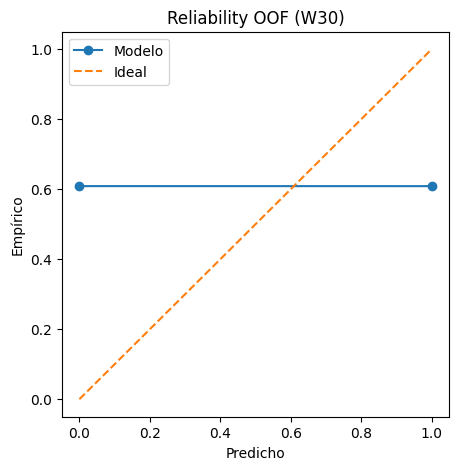

,mean_pred,frac_pos
0,0.0,0.608880
1,1.0,0.608777


In [22]:
def plot_reliability(y_true, y_score, n_bins=15, title="Reliability (OOF)"):
    frac_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(5,5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Modelo")
    plt.plot([0,1],[0,1], linestyle="--", label="Ideal")
    plt.xlabel("Predicho")
    plt.ylabel("Empírico")
    plt.title(title)
    plt.legend()
    plt.show()
    return pd.DataFrame({"mean_pred":mean_pred, "frac_pos":frac_pos})

rel_df = plot_reliability(y, model.oof_pred_, n_bins=20, title="Reliability OOF (W30)")
display(rel_df.head(10))

# Fairness (DP & EO) por género / canal / top estados

In [23]:
# Threshold al 10% (cámbialo si tienes budget distinto)
thr_idx = int(len(y) * 0.10)
top_idx = np.argpartition(-model.oof_pred_, thr_idx-1)[:thr_idx]
y_pred_bin = np.zeros_like(y)
y_pred_bin[top_idx] = 1

def fairness_report(y_true, y_pred, sensitive: pd.Series, name: str):
    mf = MetricFrame(
        metrics={"selection_rate": lambda yt, yp: np.mean(yp),
                 "tpr": lambda yt, yp: ( (yp==1)&(yt==1) ).sum() / max(1, (yt==1).sum()),
                 "fpr": lambda yt, yp: ( (yp==1)&(yt==0) ).sum() / max(1, (yt==0).sum())
                },
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive
    )
    dp = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eo = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)
    print(f"\n=== Fairness: {name} ===")
    print(f"Demographic Parity Δ: {dp:.4f} | Equalized Odds Δ: {eo:.4f}")
    display(mf.by_group.sort_index())
    return {"dp_diff": dp, "eo_diff": eo}

fair_gender = fairness_report(y, y_pred_bin, meta["gender"], "Género")
fair_channel = fairness_report(y, y_pred_bin, meta["channelDetail"], "Canal")
# Estados: limitemos a top-10 por volumen para no saturar
top_states = meta["state_abbr"].value_counts().head(10).index.tolist()
fair_state = fairness_report(y, y_pred_bin, meta["state_abbr"].where(meta["state_abbr"].isin(top_states), "OT"), "Estado (Top10+OT)")



=== Fairness: Género ===
Demographic Parity Δ: 0.0023 | Equalized Odds Δ: 0.0032


,selection_rate,tpr,fpr
gender,,,
female,0.098807,0.070745,0.147363
male,0.101135,0.067575,0.148466



=== Fairness: Canal ===
Demographic Parity Δ: 0.1178 | Equalized Odds Δ: 0.1594


,selection_rate,tpr,fpr
channelDetail,,,
COLLABORATOR,0.096251,0.052199,0.159405
DIGITAL,0.000000,0.000000,0.000000
DIGITAL_ORGANIC,0.105281,0.064778,0.150516
ORGANIC,0.106767,0.067469,0.149916
POS,0.095862,0.069816,0.146644
SPIN_PREMIA,0.117794,0.075236,0.145985



=== Fairness: Estado (Top10+OT) ===
Demographic Parity Δ: 0.0131 | Equalized Odds Δ: 0.0179


,selection_rate,tpr,fpr
state_abbr,,,
BC,0.100274,0.064797,0.148359
CH,0.096281,0.061455,0.145179
DF,0.103056,0.067754,0.149908
EM,0.089935,0.067986,0.148228
GT,0.102347,0.074790,0.150149
JA,0.099379,0.070336,0.146894
NL,0.096621,0.058189,0.150153
OT,0.101623,0.070102,0.147815
PU,0.095251,0.076117,0.143743


# PSI de score (drift simple entre folds)

In [24]:
def _psi(a: np.ndarray, b: np.ndarray, bins=10) -> float:
    eps = 1e-9
    qs = np.quantile(a, np.linspace(0,1,bins+1))
    qs[0] -= 1e-6; qs[-1] += 1e-6
    a_counts, _ = np.histogram(a, bins=qs)
    b_counts, _ = np.histogram(b, bins=qs)
    a_rat = a_counts / max(1, a_counts.sum())
    b_rat = b_counts / max(1, b_counts.sum())
    return float(np.sum((b_rat - a_rat) * np.log((b_rat+eps)/(a_rat+eps))))

# PSI entre 1ra mitad y 2da mitad cronológica
order = np.argsort(time_order)
mid = len(order)//2
psi_score = _psi(model.oof_pred_[order[:mid]], model.oof_pred_[order[mid:]])
print(f"PSI(score) 1H vs 2H = {psi_score:.4f}  (<=0.1 estable, 0.1~0.2 leve, 0.2~0.3 moderado, >0.3 alto)")

PSI(score) 1H vs 2H = 0.0001  (<=0.1 estable, 0.1~0.2 leve, 0.2~0.3 moderado, >0.3 alto)
